In [1]:
from dambuhala import *

# Tests

1. Wang et al (2018) empirical equation for peak discharge
2. Generation of hydrograph from empirical equations and beta distribution

TOTAL WATER VOLUME (m^3): 35706600.0
PEAK DISCHARGE (m^3/s): 2276.5465621175376
(a,b)		duration	(sum of volume slices)
(4.57, 8.86) 	 13.43 		 9918.495914530224
(3.14, 7.13) 	 12.26 		 9918.885544916451
(1.65, 3.09) 	 8.1 		 9916.891329308914
(2.91, 8.38) 	 13.87 		 9918.534990978887
(3.82, 6.66) 	 11.61 		 9918.570756947774


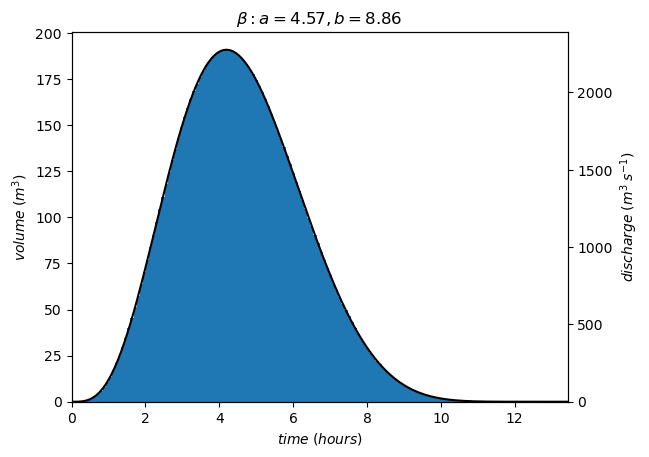

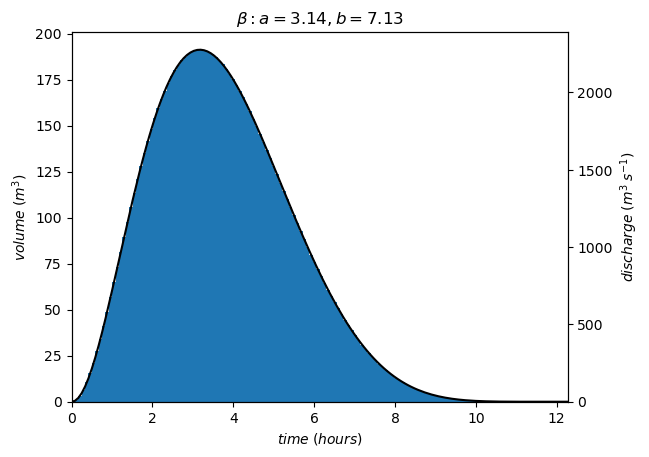

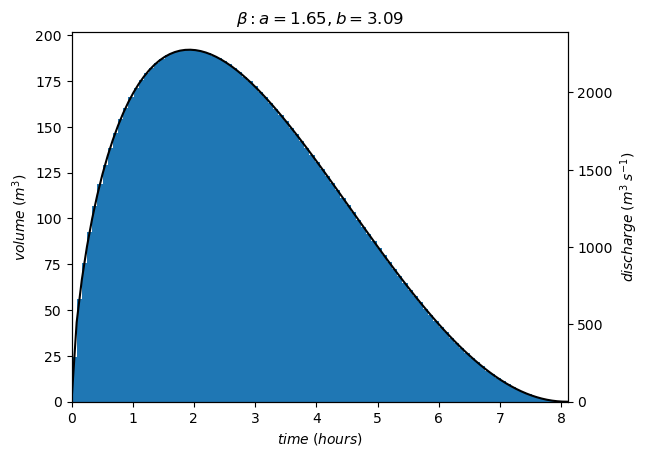

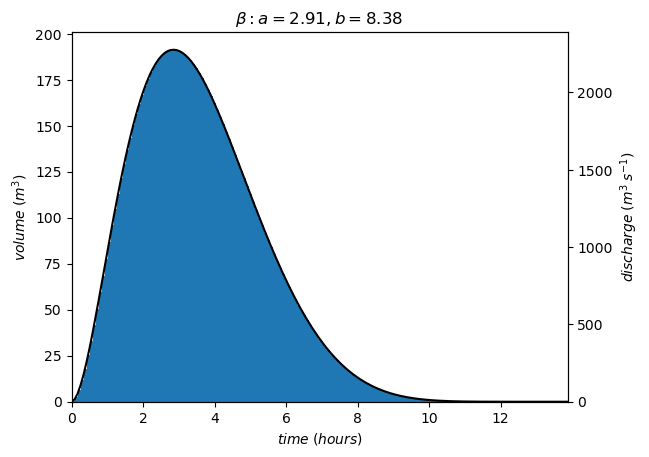

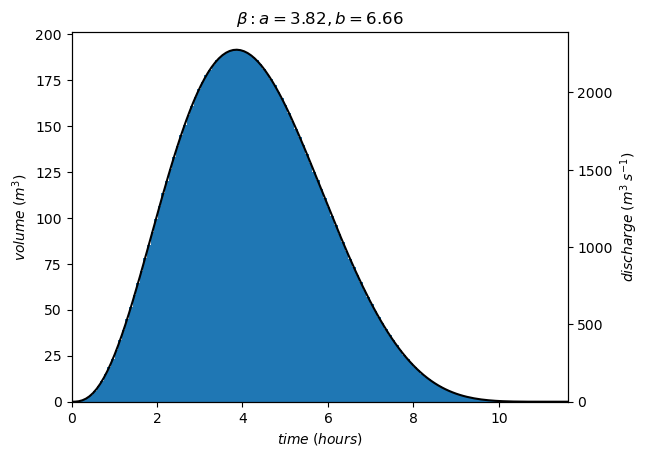

In [17]:

# Use Wang et al (2018) empirical equation to compute peak discharge from volume and heigh of water above breach
Vw=35706600.0
Hw=50
Qp=wang_etal_2018_eq4(Vw,Hw)



#initialize hydrograph
dt=1/12   # set target time step for hydrograph, in hours
minpeakloc=0.1
maxpeakloc=0.5
hg=hydrograph_BetaDist(Vw,Qp,dt,minpeakloc=minpeakloc,maxpeakloc=maxpeakloc)
plt.close("all")
v=0
print(f'TOTAL WATER VOLUME (m^3): {hg.Vw}')
print(f'PEAK DISCHARGE (m^3/s): {hg.Qp}')
print(f'(a,b)\t\tduration\t(sum of volume slices)')
    
for p in hg.valid_beta_params[:min(5,len(hg.valid_beta_params))]:
    t,q,v=hg.make_hydrograph(p[0],p[1],plot=True)
    print((float(p[0]),float(p[1])),"\t",np.round(hg.T,2),"\t\t",np.sum(hg.v))
  